# 🚨 Predictive Crime Analysis and Hotspot Detection

**Academic Final Year Project**  
**Domain:** Machine Learning, Crime Data Analysis, Geospatial Intelligence  
**Technologies:** Python, Scikit-Learn, Pandas, NumPy, Seaborn, Matplotlib, Joblib

---

## 🔹 Project Overview
This project implements a complete Machine Learning and Geospatial Analytics pipeline to analyze historical crime incidents, identify crime hotspots, predict the risk of future crimes, and group incident areas into risk zones using clustering. The models trained in this notebook are exported to be loaded into an interactive Streamlit Command Center web application.

### Workflow:
1. **Data Loading & Preprocessing:** Cleaning data, handling missing values, and formatting temporal fields.
2. **Exploratory Data Analysis (EDA):** Visualizing distributions, trends, and geospatial coordinates.
3. **Feature Engineering:** Extracting spatial-temporal features and label encoding.
4. **Machine Learning Modeling:**
   - **Hotspot Classification:** Random Forest Classifier to identify high-density crime hotspots.
   - **Future Crime Prediction (Risk Score):** Estimating the probability of crime severity.
   - **Geospatial Clustering:** K-Means Clustering on coordinates to partition regions into High, Medium, and Low Risk Zones.
5. **Model Exporting:** Exporting classifiers, scalers, and encoders via Joblib.

In [16]:
# 1. Import Required Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# Set visualization settings
%matplotlib inline
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

## 🔹 Data Loading and Inspection

In [17]:
# 2. Load the Dataset
dataset_path = 'dataset.csv'
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"Dataset not found at {dataset_path}. Please generate it first.")

df = pd.read_csv(dataset_path)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (6000, 15)


,crime_id,date,time,city,area,latitude,longitude,crime_type,severity_level,day_of_week,month,year,arrest_made,crime_status,hotspot_label
0,CRIME-1000,2023-08-17,18:01:47,Chennai,Nungambakkam,13.059374,80.242107,Burglary,Medium,Thursday,8,2023,Yes,Solved,0
1,CRIME-1001,2023-10-13,22:47:06,Vijayawada,Moghalrajpuram,16.503446,80.635970,Vehicle Theft,Medium,Friday,10,2023,No,Under Investigation,0
2,CRIME-1002,2023-06-28,20:37:27,Delhi,Vasant Kunj,28.524302,77.161643,Theft,Medium,Wednesday,6,2023,Yes,Solved,0
3,CRIME-1003,2024-03-23,16:14:32,Mumbai,Thane,19.213959,72.978589,Cyber Crime,Medium,Saturday,3,2024,Yes,Under Investigation,0
4,CRIME-1004,2024-02-12,21:45:41,Hyderabad,Dilsukhnagar,17.371723,78.522849,Vehicle Theft,Medium,Monday,2,2024,No,Unsolved,1


In [18]:
# Display columns, null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crime_id        6000 non-null   object 
 1   date            6000 non-null   object 
 2   time            6000 non-null   object 
 3   city            6000 non-null   object 
 4   area            6000 non-null   object 
 5   latitude        6000 non-null   float64
 6   longitude       6000 non-null   float64
 7   crime_type      6000 non-null   object 
 8   severity_level  6000 non-null   object 
 9   day_of_week     6000 non-null   object 
 10  month           6000 non-null   int64  
 11  year            6000 non-null   int64  
 12  arrest_made     6000 non-null   object 
 13  crime_status    6000 non-null   object 
 14  hotspot_label   6000 non-null   int64  
dtypes: float64(2), int64(3), object(10)
memory usage: 703.2+ KB


In [19]:
# Summary statistics
df.describe(include='all')

,crime_id,date,time,city,area,latitude,longitude,crime_type,severity_level,day_of_week,month,year,arrest_made,crime_status,hotspot_label
count,6000,6000,6000,6000,6000,6000.000000,6000.000000,6000,6000,6000,6000.000000,6000.000000,6000,6000,6000.000000
unique,6000,1093,5728,6,60,NaN,NaN,7,3,7,NaN,NaN,2,3,NaN
top,CRIME-1000,2024-04-29,18:23:07,Delhi,Kurla,NaN,NaN,Robbery,Medium,Tuesday,NaN,NaN,No,Unsolved,NaN
freq,1,13,3,1201,180,NaN,NaN,876,3231,910,NaN,NaN,4195,2275,NaN
mean,NaN,NaN,NaN,NaN,NaN,18.504229,77.654157,NaN,NaN,NaN,6.562833,2023.997667,NaN,NaN,0.411833
std,NaN,NaN,NaN,NaN,NaN,5.520848,2.585811,NaN,NaN,NaN,3.430988,0.827109,NaN,NaN,0.492206
min,NaN,NaN,NaN,NaN,NaN,12.834746,72.801672,NaN,NaN,NaN,1.000000,2023.000000,NaN,NaN,0.000000
25%,NaN,NaN,NaN,NaN,NaN,13.044032,77.186904,NaN,NaN,NaN,4.000000,2023.000000,NaN,NaN,0.000000
50%,NaN,NaN,NaN,NaN,NaN,17.414174,77.669182,NaN,NaN,NaN,7.000000,2024.000000,NaN,NaN,0.000000
75%,NaN,NaN,NaN,NaN,NaN,19.115818,80.216829,NaN,NaN,NaN,10.000000,2025.000000,NaN,NaN,1.000000


## 🔹 Data Preprocessing and Cleaning
We verify there are no missing values and correct the format of dates and times.

In [20]:
# 3. Missing Values and Duplicates Check
print("Missing Values:\n", df.isnull().sum())
print(f"\nDuplicate Rows Count: {df.duplicated().sum()}")

# Clean column data if necessary
df['date'] = pd.to_datetime(df['date'])
df['hour'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.hour
print(f"Extracted 'hour' feature from 'time'.")

Missing Values:
 crime_id          0
date              0
time              0
city              0
area              0
latitude          0
longitude         0
crime_type        0
severity_level    0
day_of_week       0
month             0
year              0
arrest_made       0
crime_status      0
hotspot_label     0
dtype: int64

Duplicate Rows Count: 0
Extracted 'hour' feature from 'time'.


## 🔹 Exploratory Data Analysis (EDA)
We perform visual analysis to uncover patterns in crime occurrence across cities, time, and severity.

C:\Users\visha\AppData\Local\Temp\ipykernel_13536\388803593.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='crime_type', order=df['crime_type'].value_counts().index, palette='viridis')


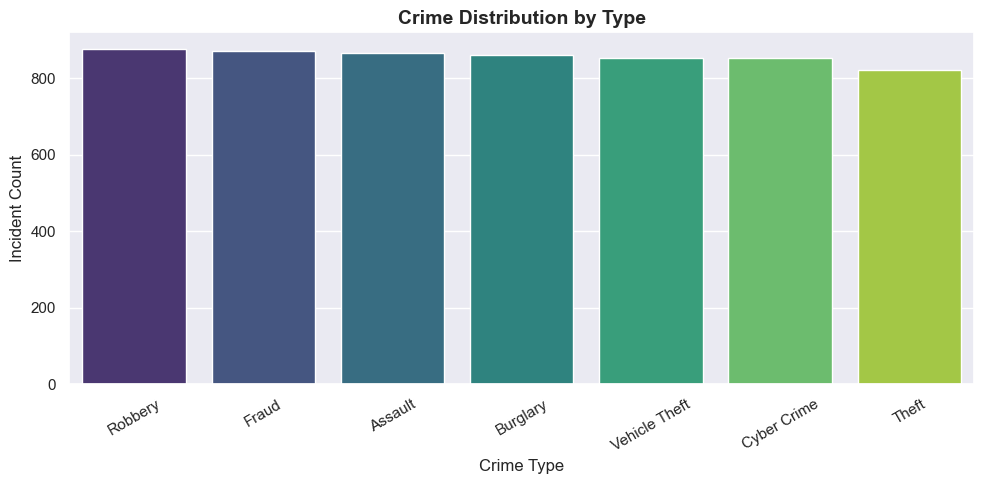

In [21]:
# Visual 1: Crime Type Distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='crime_type', order=df['crime_type'].value_counts().index, palette='viridis')
plt.title('Crime Distribution by Type', fontsize=14, fontweight='bold')
plt.xlabel('Crime Type')
plt.ylabel('Incident Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

C:\Users\visha\AppData\Local\Temp\ipykernel_13536\3603975227.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='month', palette='coolwarm')


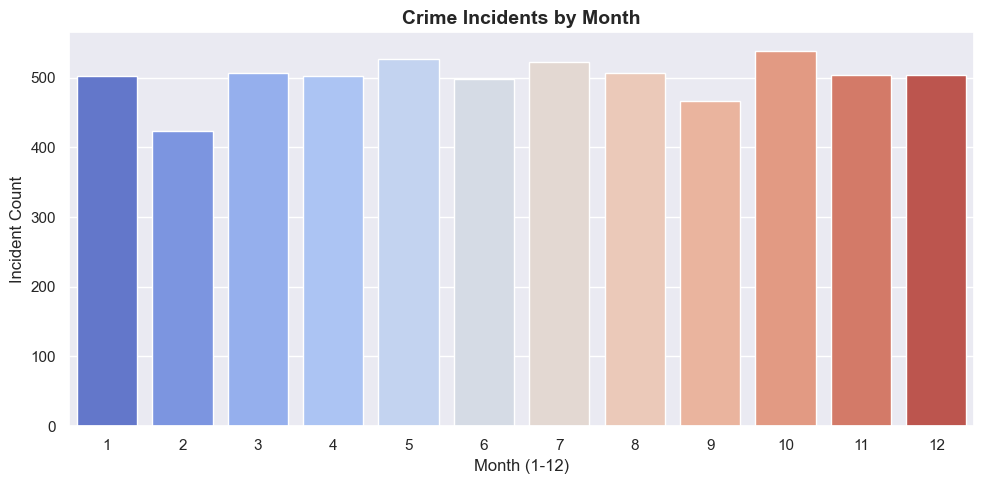

In [22]:
# Visual 2: Crime Trends by Month
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='month', palette='coolwarm')
plt.title('Crime Incidents by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month (1-12)')
plt.ylabel('Incident Count')
plt.tight_layout()
plt.show()

C:\Users\visha\AppData\Local\Temp\ipykernel_13536\905537913.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='city', order=df['city'].value_counts().index, palette='plasma')


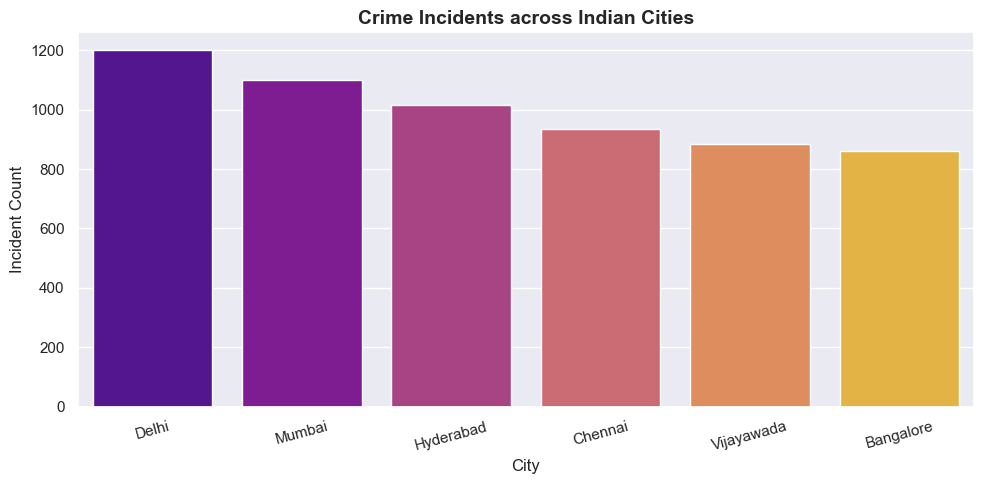

In [23]:
# Visual 3: Crime Distribution by City
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='city', order=df['city'].value_counts().index, palette='plasma')
plt.title('Crime Incidents across Indian Cities', fontsize=14, fontweight='bold')
plt.xlabel('City')
plt.ylabel('Incident Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

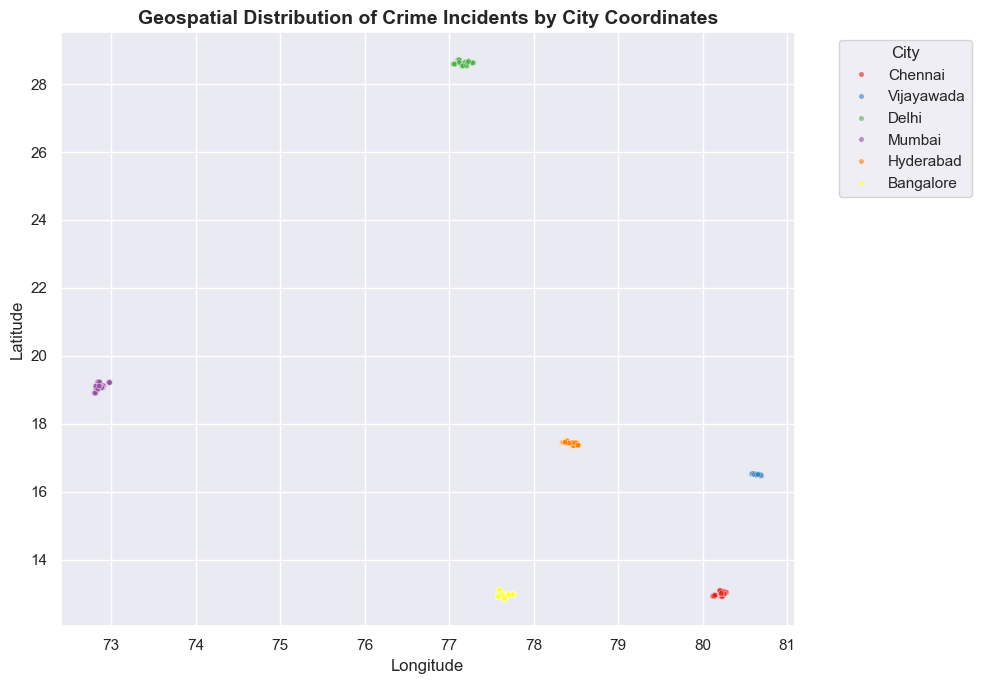

In [24]:
# Visual 4: Geospatial Scatter of Crime Incidents
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='city', palette='Set1', alpha=0.6, s=15)
plt.title('Geospatial Distribution of Crime Incidents by City Coordinates', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='City', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

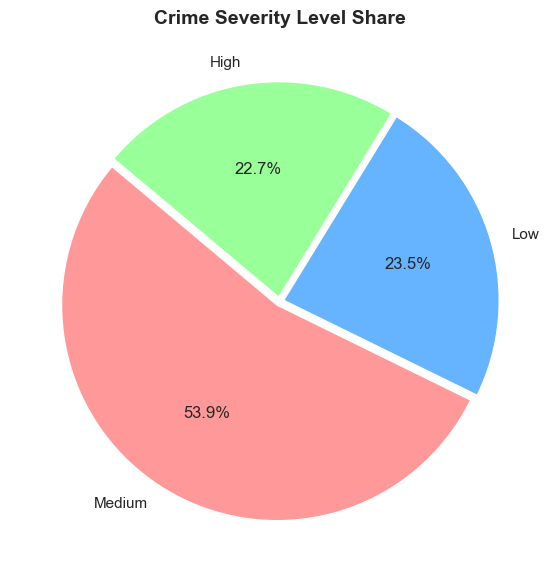

In [25]:
# Visual 5: Severity Level Analysis
plt.figure(figsize=(7, 7))
df['severity_level'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'], startangle=140, explode=(0.02, 0.02, 0.02))
plt.title('Crime Severity Level Share', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.show()

## 🔹 Feature Engineering & Label Encoding
We convert categorical features into numerical values using `LabelEncoder`. All encoders are saved to map user inputs in the Streamlit application.

In [26]:
# Encode categorical variables
categorical_cols = ['city', 'area', 'crime_type', 'severity_level', 'day_of_week']
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded {col}: classes found {le.classes_[:5]}...")

# Build features list for models
features = ['city_encoded', 'area_encoded', 'crime_type_encoded', 'hour', 'day_of_week_encoded', 'month']
print("\nFeatures selected for modeling:", features)

Encoded city: classes found ['Bangalore' 'Chennai' 'Delhi' 'Hyderabad' 'Mumbai']...
Encoded area: classes found ['Adyar' 'Andheri' 'Anna Nagar' 'Auto Nagar' 'Bandra']...
Encoded crime_type: classes found ['Assault' 'Burglary' 'Cyber Crime' 'Fraud' 'Robbery']...
Encoded severity_level: classes found ['High' 'Low' 'Medium']...
Encoded day_of_week: classes found ['Friday' 'Monday' 'Saturday' 'Sunday' 'Thursday']...

Features selected for modeling: ['city_encoded', 'area_encoded', 'crime_type_encoded', 'hour', 'day_of_week_encoded', 'month']


## 🔹 Model A: Crime Hotspot Classification
Predict whether a location is a hotspot (`hotspot_label = 1`) or not (`0`). We use a `RandomForestClassifier`.

In [27]:
# Prepare training data
X_hotspot = df[features]
y_hotspot = df['hotspot_label']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_hotspot, y_hotspot, test_size=0.25, random_state=42, stratify=y_hotspot)

# Train Random Forest Classifier
hotspot_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
hotspot_classifier.fit(X_train_h, y_train_h)

# Evaluate Model
y_pred_h = hotspot_classifier.predict(X_test_h)
accuracy_h = accuracy_score(y_test_h, y_pred_h)

print(f"Hotspot Classifier Accuracy: {accuracy_h:.4f}\n")
print("Confusion Matrix:\n", confusion_matrix(y_test_h, y_pred_h))
print("\nClassification Report:\n", classification_report(y_test_h, y_pred_h))

Hotspot Classifier Accuracy: 0.9767

Confusion Matrix:
 [[880   2]
 [ 33 585]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       882
           1       1.00      0.95      0.97       618

    accuracy                           0.98      1500
   macro avg       0.98      0.97      0.98      1500
weighted avg       0.98      0.98      0.98      1500



## 🔹 Model B: Future Crime Prediction (Risk Score)
Predict whether a future crime incident will be a High/Medium Severity crime. The probability score computed represents the `Crime Risk Score`.
We define a binary target `high_risk_flag = 1` if `severity_level` is `High` or `Medium`, else `0`.

In [28]:
# Define binary target for risk prediction (High/Medium Severity = 1, Low Severity = 0)
df['high_risk_flag'] = df['severity_level'].apply(lambda x: 1 if x in ['High', 'Medium'] else 0)

X_risk = df[features]
y_risk = df['high_risk_flag']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_risk, y_risk, test_size=0.25, random_state=42, stratify=y_risk)

# Train Classifier for Risk Estimation
risk_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=12)
risk_model.fit(X_train_r, y_train_r)

# Evaluate Model
y_pred_r = risk_model.predict(X_test_r)
accuracy_r = accuracy_score(y_test_r, y_pred_r)

print(f"Risk Prediction Classifier Accuracy: {accuracy_r:.4f}\n")
print(classification_report(y_test_r, y_pred_r))

Risk Prediction Classifier Accuracy: 0.8547

              precision    recall  f1-score   support

           0       0.67      0.74      0.71       353
           1       0.92      0.89      0.90      1147

    accuracy                           0.85      1500
   macro avg       0.80      0.81      0.80      1500
weighted avg       0.86      0.85      0.86      1500



## 🔹 Model C: Crime Clustering
We cluster the geospatial coordinates (latitude and longitude) into 3 distinct zones. We will scale the inputs and then apply K-Means Clustering, labeling clusters as High, Medium, or Low Risk based on crime frequency in each cluster.

Cluster Mapping based on incident counts: {1: 'High Risk Zone', 0: 'Medium Risk Zone', 2: 'Low Risk Zone'}


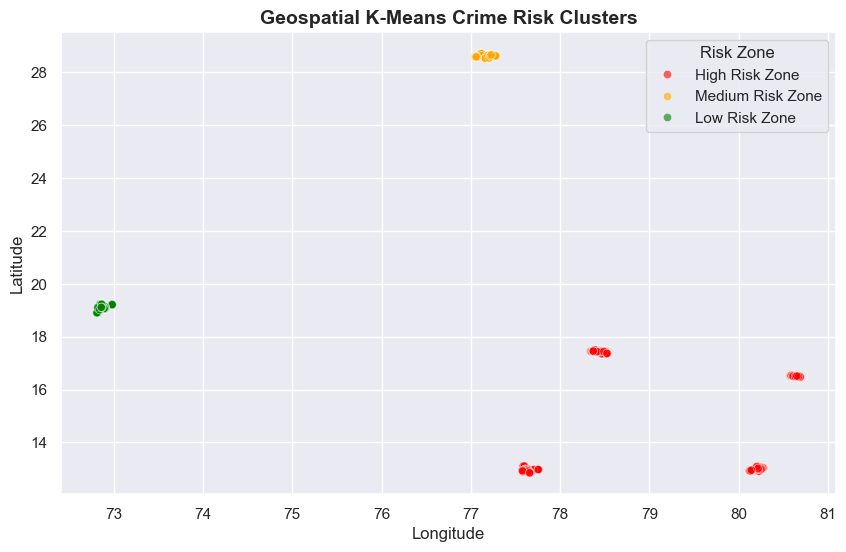

In [29]:
# Scale coordinates
scaler = StandardScaler()
coords = df[['latitude', 'longitude']]
coords_scaled = scaler.fit_transform(coords)

# Train K-Means Clustering Model (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(coords_scaled)

# Rank clusters to identify Risk Zone labels (High, Medium, Low Risk Zone)
# Rank by count of crime incidents in each cluster
cluster_counts = df['cluster'].value_counts()
sorted_clusters = cluster_counts.index.tolist()

# Map cluster index to label
risk_mapping = {
    sorted_clusters[0]: "High Risk Zone",
    sorted_clusters[1]: "Medium Risk Zone",
    sorted_clusters[2]: "Low Risk Zone"
}
df['risk_zone'] = df['cluster'].map(risk_mapping)
print("Cluster Mapping based on incident counts:", risk_mapping)

# Visualizing Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='longitude', y='latitude', hue='risk_zone', palette={'High Risk Zone': 'red', 'Medium Risk Zone': 'orange', 'Low Risk Zone': 'green'}, alpha=0.6)
plt.title('Geospatial K-Means Crime Risk Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Risk Zone')
plt.show()

## 🔹 Model Saving
We save the models, scaler, encoders, and feature column names to joblib files so the Streamlit application can load them to perform real-time inferences.

In [30]:
# Save trained models and encoders using joblib
joblib.dump(hotspot_classifier, 'crime_classifier.joblib')
joblib.dump(risk_model, 'crime_forecast_model.joblib')
joblib.dump((kmeans, risk_mapping), 'crime_cluster_model.joblib')
joblib.dump(label_encoders, 'label_encoders.joblib')
joblib.dump(features, 'feature_columns.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("All ML artifacts exported successfully:")
print("- crime_classifier.joblib (Hotspot classifier)")
print("- crime_forecast_model.joblib (Risk prediction classifier)")
print("- crime_cluster_model.joblib (KMeans cluster + mapping dict)")
print("- label_encoders.joblib (Label encoders)")
print("- feature_columns.joblib (Feature names list)")
print("- scaler.joblib (StandardScaler for lat/lon coordinates)")

All ML artifacts exported successfully:
- crime_classifier.joblib (Hotspot classifier)
- crime_forecast_model.joblib (Risk prediction classifier)
- crime_cluster_model.joblib (KMeans cluster + mapping dict)
- label_encoders.joblib (Label encoders)
- feature_columns.joblib (Feature names list)
- scaler.joblib (StandardScaler for lat/lon coordinates)
